In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,Order_ID,Region,Segment,Category,Sub_Category,Year,Month,Quantity,Unit_Cost,Unit_Price,Discount,Sales,Profit,Date
0,1,Centre,Entreprise,Office Supplies,Storage,2025,1,3,218.25,241.63,0.20,724.90,70.15,2025-01-01
1,2,Nord,Corporate,Office Supplies,Binders,2023,5,2,210.70,231.70,0.20,463.41,42.01,2023-05-01
2,3,Sud,Entreprise,Furniture,Chairs,2024,7,5,109.20,138.91,0.05,694.57,148.57,2024-07-01
3,4,Sud,Entreprise,Office Supplies,Binders,2023,9,5,133.25,154.35,0.15,771.73,105.48,2023-09-01
4,5,Centre,Corporate,Office Supplies,Storage,2022,12,6,442.10,506.04,0.15,3036.21,383.61,2022-12-01


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      1200 non-null   int64  
 1   Region        1200 non-null   object 
 2   Segment       1200 non-null   object 
 3   Category      1200 non-null   object 
 4   Sub_Category  1200 non-null   object 
 5   Year          1200 non-null   int64  
 6   Month         1200 non-null   int64  
 7   Quantity      1200 non-null   int64  
 8   Unit_Cost     1200 non-null   float64
 9   Unit_Price    1200 non-null   float64
 10  Discount      1200 non-null   float64
 11  Sales         1200 non-null   float64
 12  Profit        1200 non-null   float64
 13  Date          1200 non-null   object 
dtypes: float64(5), int64(4), object(5)
memory usage: 131.4+ KB


In [4]:
df.describe()

,Order_ID,Year,Month,Quantity,Unit_Cost,Unit_Price,Discount,Sales,Profit
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,2023.509167,6.614167,4.917500,258.806708,310.824450,0.097958,1529.698250,255.016692
std,346.554469,1.125154,3.465589,2.577058,139.062286,167.600481,0.069596,1231.114966,235.499168
min,1.000000,2022.000000,1.000000,1.000000,20.060000,18.020000,0.000000,24.530000,-36.080000
25%,300.750000,2022.000000,4.000000,3.000000,139.532500,166.790000,0.050000,554.860000,84.392500
50%,600.500000,2024.000000,7.000000,5.000000,254.200000,305.055000,0.100000,1155.925000,182.765000
75%,900.250000,2025.000000,9.250000,7.000000,382.582500,455.327500,0.150000,2266.320000,347.012500
max,1200.000000,2025.000000,12.000000,9.000000,499.640000,650.370000,0.200000,5691.620000,1341.490000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Order_ID        0
Region          0
Segment         0
Category        0
Sub_Category    0
Year            0
Month           0
Quantity        0
Unit_Cost       0
Unit_Price      0
Discount        0
Sales           0
Profit          0
Date            0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

Order_ID        0
Region          0
Segment         0
Category        0
Sub_Category    0
Year            0
Month           0
Quantity        0
Unit_Cost       0
Unit_Price      0
Discount        0
Sales           0
Profit          0
Date            0
dtype: int64

In [9]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2) + "-01")

In [10]:
df.head()

,Order_ID,Region,Segment,Category,Sub_Category,Year,Month,Quantity,Unit_Cost,Unit_Price,Discount,Sales,Profit,Date
0,1,Centre,Entreprise,Office Supplies,Storage,2025,1,3,218.25,241.63,0.20,724.90,70.15,2025-01-01
1,2,Nord,Corporate,Office Supplies,Binders,2023,5,2,210.70,231.70,0.20,463.41,42.01,2023-05-01
2,3,Sud,Entreprise,Furniture,Chairs,2024,7,5,109.20,138.91,0.05,694.57,148.57,2024-07-01
3,4,Sud,Entreprise,Office Supplies,Binders,2023,9,5,133.25,154.35,0.15,771.73,105.48,2023-09-01
4,5,Centre,Corporate,Office Supplies,Storage,2022,12,6,442.10,506.04,0.15,3036.21,383.61,2022-12-01


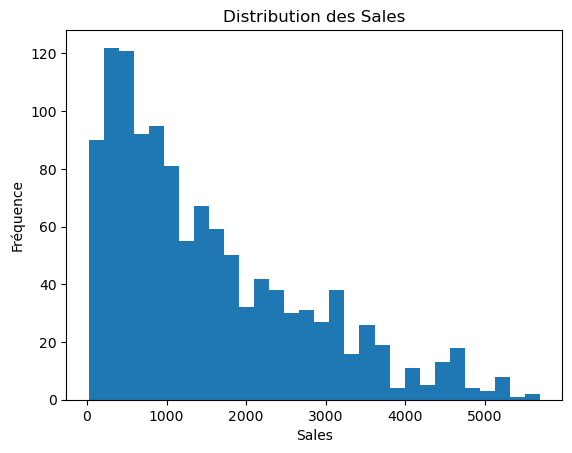

In [11]:
plt.hist(df['Sales'], bins=30)
plt.title("Distribution des Sales")
plt.xlabel("Sales")
plt.ylabel("Fréquence")
plt.show()

In [12]:
print("Moyenne:", df['Sales'].mean())
print("Min:", df['Sales'].min())
print("Max:", df['Sales'].max())

Moyenne: 1529.6982500000001
Min: 24.53
Max: 5691.62


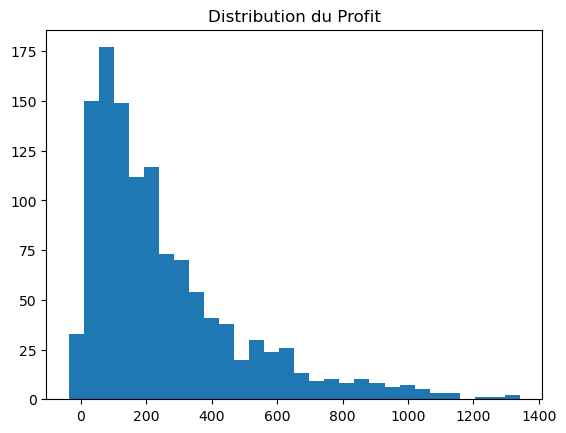

In [13]:
plt.hist(df['Profit'], bins=30)
plt.title("Distribution du Profit")
plt.show()

In [14]:
print(df['Profit'].describe())

count    1200.000000
mean      255.016692
std       235.499168
min       -36.080000
25%        84.392500
50%       182.765000
75%       347.012500
max      1341.490000
Name: Profit, dtype: float64


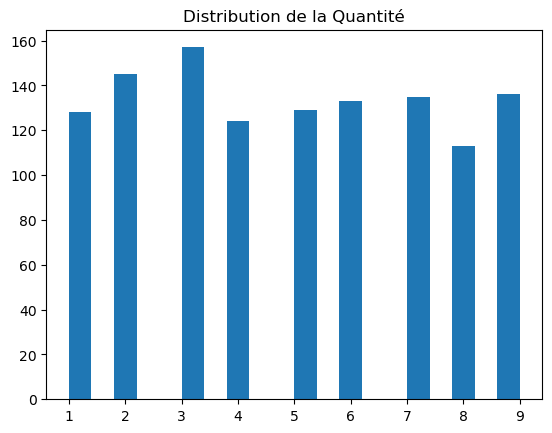

In [15]:
plt.hist(df['Quantity'], bins=20)
plt.title("Distribution de la Quantité")
plt.show()

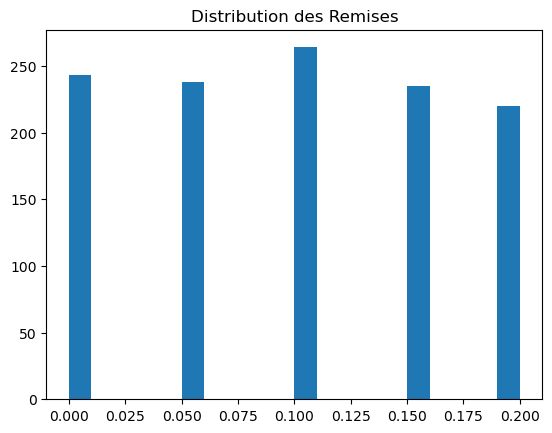

In [16]:
plt.hist(df['Discount'], bins=20)
plt.title("Distribution des Remises")
plt.show()

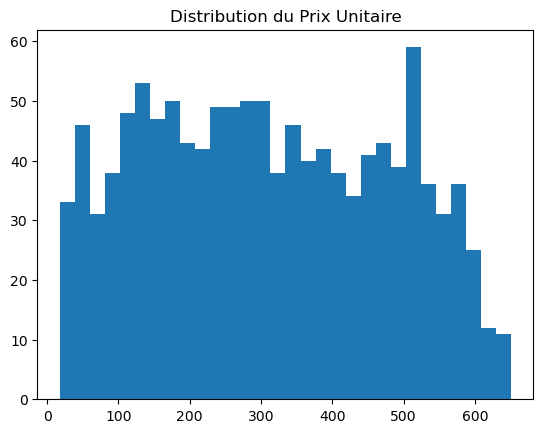

In [17]:
plt.hist(df['Unit_Price'], bins=30)
plt.title("Distribution du Prix Unitaire")
plt.show()

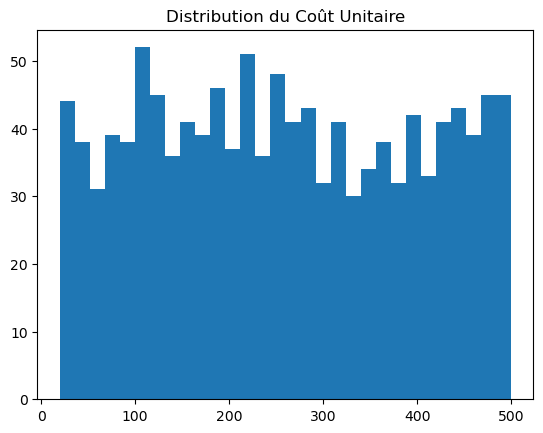

In [18]:
plt.hist(df['Unit_Cost'], bins=30)
plt.title("Distribution du Coût Unitaire")
plt.show()

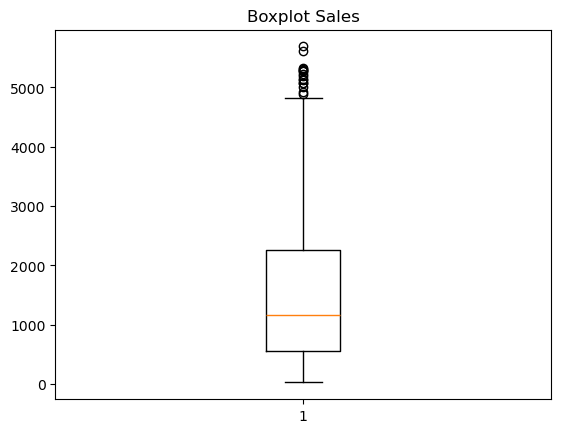

In [19]:
plt.boxplot(df['Sales'])
plt.title("Boxplot Sales")
plt.show()

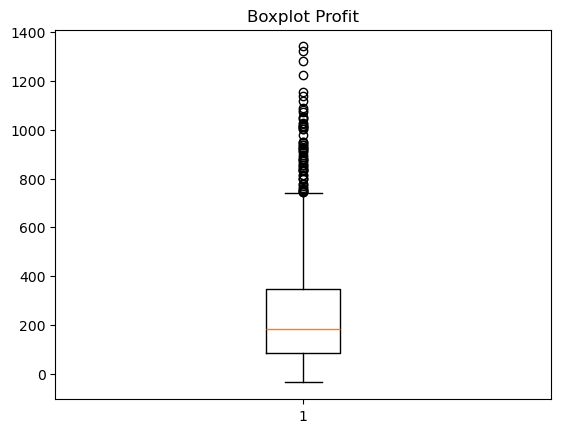

In [20]:
plt.boxplot(df['Profit'])
plt.title("Boxplot Profit")
plt.show()

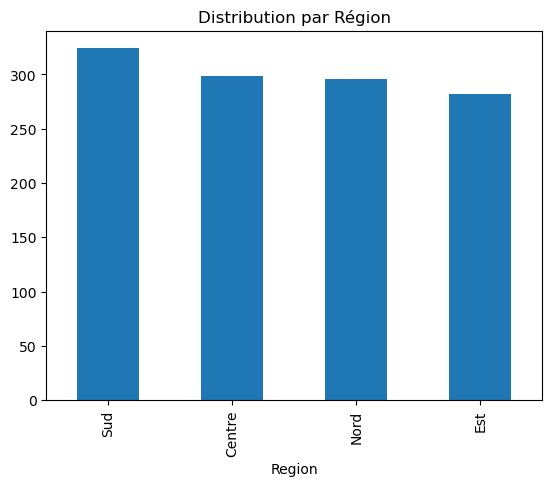

In [21]:
df['Region'].value_counts().plot(kind='bar')
plt.title("Distribution par Région")
plt.show()

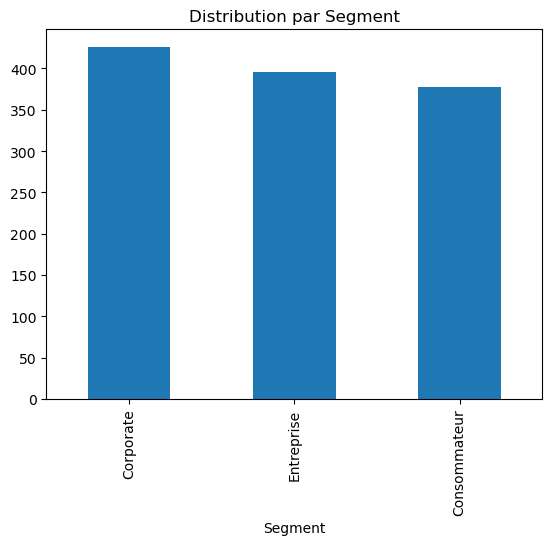

In [22]:
df['Segment'].value_counts().plot(kind='bar')
plt.title("Distribution par Segment")
plt.show()

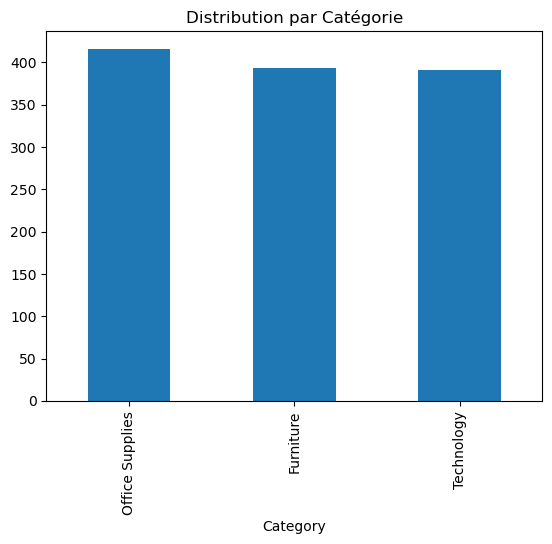

In [23]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Distribution par Catégorie")
plt.show()

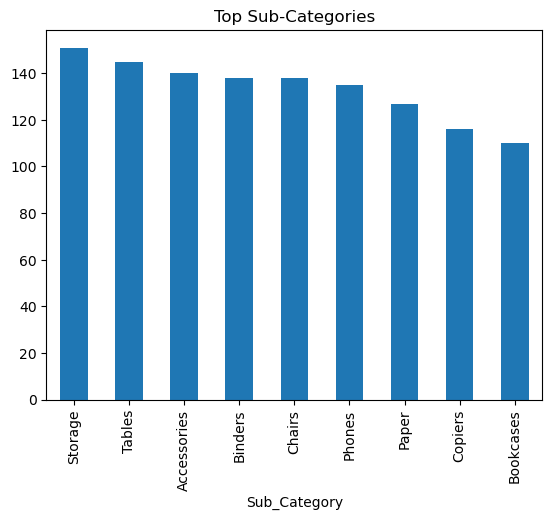

In [24]:
df['Sub_Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Sub-Categories")
plt.show()

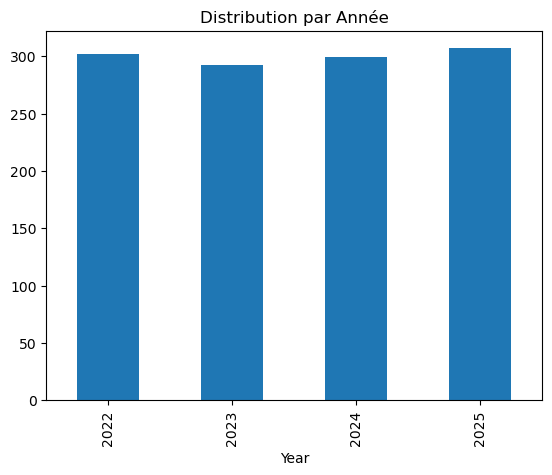

In [25]:
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution par Année")
plt.show()

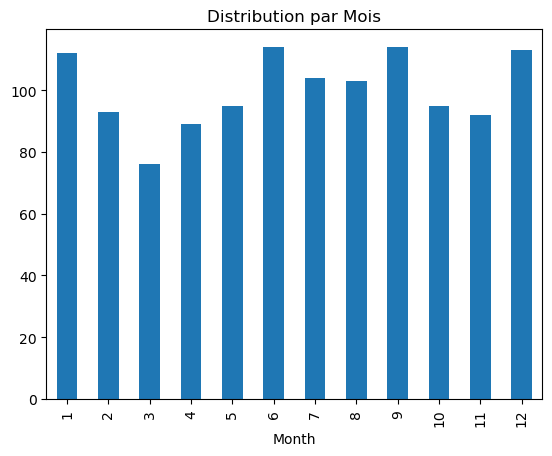

In [26]:
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution par Mois")
plt.show()

In [27]:
# Nombre total de commandes
total = df['Order_ID'].count()

# Nombre de valeurs uniques
unique = df['Order_ID'].nunique()

# Nombre de doublons
doublons = df['Order_ID'].duplicated().sum()

print("Total:", total)
print("Unique:", unique)
print("Doublons:", doublons)

Total: 1200
Unique: 1200
Doublons: 0


In [28]:
df.to_csv("cleaned_data.csv", index=False)

In [29]:
import os
print(os.getcwd())

C:\Users\dell\Desktop\PFE


In [30]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      1200 non-null   int64         
 1   Region        1200 non-null   object        
 2   Segment       1200 non-null   object        
 3   Category      1200 non-null   object        
 4   Sub_Category  1200 non-null   object        
 5   Year          1200 non-null   int64         
 6   Month         1200 non-null   int64         
 7   Quantity      1200 non-null   int64         
 8   Unit_Cost     1200 non-null   float64       
 9   Unit_Price    1200 non-null   float64       
 10  Discount      1200 non-null   float64       
 11  Sales         1200 non-null   float64       
 12  Profit        1200 non-null   float64       
 13  Date          1200 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(4), object(4)
memory usage: 131.4+ KB


In [31]:
print(df.head())
print(df.info())

   Order_ID  Region     Segment         Category Sub_Category  Year  Month  \
0         1  Centre  Entreprise  Office Supplies      Storage  2025      1   
1         2    Nord   Corporate  Office Supplies      Binders  2023      5   
2         3     Sud  Entreprise        Furniture       Chairs  2024      7   
3         4     Sud  Entreprise  Office Supplies      Binders  2023      9   
4         5  Centre   Corporate  Office Supplies      Storage  2022     12   

   Quantity  Unit_Cost  Unit_Price  Discount    Sales  Profit       Date  
0         3     218.25      241.63      0.20   724.90   70.15 2025-01-01  
1         2     210.70      231.70      0.20   463.41   42.01 2023-05-01  
2         5     109.20      138.91      0.05   694.57  148.57 2024-07-01  
3         5     133.25      154.35      0.15   771.73  105.48 2023-09-01  
4         6     442.10      506.04      0.15  3036.21  383.61 2022-12-01  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data co

In [32]:
df['Date'] = pd.to_datetime(df['Date'])

print(f'Shape : {df.shape}')
print(f'Période : {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

Shape : (1200, 14)
Période : 2022-01-01 → 2025-12-01


,Order_ID,Region,Segment,Category,Sub_Category,Year,Month,Quantity,Unit_Cost,Unit_Price,Discount,Sales,Profit,Date
0,1,Centre,Entreprise,Office Supplies,Storage,2025,1,3,218.25,241.63,0.20,724.90,70.15,2025-01-01
1,2,Nord,Corporate,Office Supplies,Binders,2023,5,2,210.70,231.70,0.20,463.41,42.01,2023-05-01
2,3,Sud,Entreprise,Furniture,Chairs,2024,7,5,109.20,138.91,0.05,694.57,148.57,2024-07-01
3,4,Sud,Entreprise,Office Supplies,Binders,2023,9,5,133.25,154.35,0.15,771.73,105.48,2023-09-01
4,5,Centre,Corporate,Office Supplies,Storage,2022,12,6,442.10,506.04,0.15,3036.21,383.61,2022-12-01


In [33]:
df[['Sales', 'Profit']].describe().round(2)

,Sales,Profit
count,1200.00,1200.00
mean,1529.70,255.02
std,1231.11,235.50
min,24.53,-36.08
25%,554.86,84.39
50%,1155.92,182.76
75%,2266.32,347.01
max,5691.62,1341.49


In [34]:
# Encodage des variables catégorielles
le = LabelEncoder()
cat_cols = ['Region', 'Segment', 'Category', 'Sub_Category']
df_ml = df.copy()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Variables explicatives
features = ['Region', 'Segment', 'Category', 'Sub_Category',
            'Year', 'Month', 'Quantity', 'Unit_Cost', 'Unit_Price', 'Discount']

X = df_ml[features]
y_sales  = df_ml['Sales']
y_profit = df_ml['Profit']

# Split 80/20 (même index pour les deux cibles)
X_train, X_test, ys_train, ys_test = train_test_split(X, y_sales,  test_size=0.2, random_state=42)
_,       _,      yp_train, yp_test = train_test_split(X, y_profit, test_size=0.2, random_state=42)

print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

Train : 960 lignes | Test : 240 lignes


In [35]:
# Standardisation — obligatoire pour la régression linéaire
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# OLS
lr_sales  = LinearRegression(); lr_sales.fit(X_train_sc, ys_train)
lr_profit = LinearRegression(); lr_profit.fit(X_train_sc, yp_train)
ys_pred_lr = lr_sales.predict(X_test_sc)
yp_pred_lr = lr_profit.predict(X_test_sc)

# Ridge (L2)
ridge_sales  = Ridge(alpha=1.0); ridge_sales.fit(X_train_sc, ys_train)
ridge_profit = Ridge(alpha=1.0); ridge_profit.fit(X_train_sc, yp_train)
ys_pred_ridge = ridge_sales.predict(X_test_sc)
yp_pred_ridge = ridge_profit.predict(X_test_sc)

# Lasso (L1)
lasso_sales  = Lasso(alpha=1.0); lasso_sales.fit(X_train_sc, ys_train)
lasso_profit = Lasso(alpha=1.0); lasso_profit.fit(X_train_sc, yp_train)
ys_pred_lasso = lasso_sales.predict(X_test_sc)
yp_pred_lasso = lasso_profit.predict(X_test_sc)

print(' Modèles Régression Linéaire entraînés (OLS, Ridge, Lasso)')

 Modèles Régression Linéaire entraînés (OLS, Ridge, Lasso)


In [36]:
# Fonction utilitaire
def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'📊 {label}')
    print(f'   MAE  : {mae:>10.2f}')
    print(f'   RMSE : {rmse:>10.2f}')
    print(f'   R²   : {r2:>10.4f}\n')
    return mae, rmse, r2

print('=== Sales ===')
mae_lrs, rmse_lrs, r2_lrs = metrics(ys_test, ys_pred_lr,    'OLS   — Sales')
metrics(ys_test, ys_pred_ridge, 'Ridge — Sales')
metrics(ys_test, ys_pred_lasso, 'Lasso — Sales')

print('=== Profit ===')
mae_lrp, rmse_lrp, r2_lrp = metrics(yp_test, yp_pred_lr,    'OLS   — Profit')
metrics(yp_test, yp_pred_ridge, 'Ridge — Profit')
metrics(yp_test, yp_pred_lasso, 'Lasso — Profit')

=== Sales ===
📊 OLS   — Sales
   MAE  :     320.11
   RMSE :     432.77
   R²   :     0.8857

📊 Ridge — Sales
   MAE  :     320.31
   RMSE :     433.51
   R²   :     0.8853

📊 Lasso — Sales
   MAE  :     319.97
   RMSE :     432.82
   R²   :     0.8857

=== Profit ===
📊 OLS   — Profit
   MAE  :      61.62
   RMSE :      88.91
   R²   :     0.8704

📊 Ridge — Profit
   MAE  :      63.22
   RMSE :      92.25
   R²   :     0.8605

📊 Lasso — Profit
   MAE  :      66.17
   RMSE :      96.51
   R²   :     0.8473



(66.1669699972515, np.float64(96.50990480308457), 0.8472987564923402)

=== Coefficients OLS (variables standardisées) ===
    Variable  Coef_Sales  Coef_Profit
    Quantity  822.744026   139.987672
  Unit_Price  798.841793   799.312900
    Category  -25.212012    -3.848979
       Month   21.585709     3.311823
Sub_Category  -19.924235    -6.104008
     Segment   -6.211988    -3.303817
    Discount    5.182497    -2.288681
   Unit_Cost    3.309927  -661.320090
        Year    2.169368    -1.061579
      Region   -1.490721    -1.566141


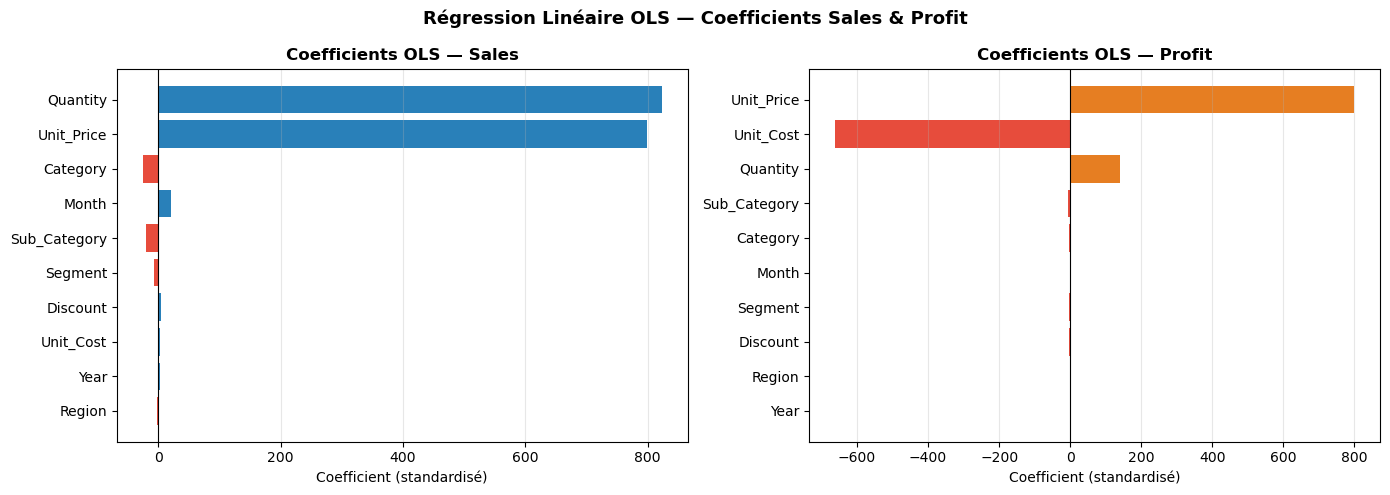

In [37]:
coef_df = pd.DataFrame({
    'Variable'    : features,
    'Coef_Sales'  : lr_sales.coef_,
    'Coef_Profit' : lr_profit.coef_,
}).sort_values('Coef_Sales', key=abs, ascending=False)
print('=== Coefficients OLS (variables standardisées) ===')
print(coef_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label, color in zip(axes,
    ['Coef_Sales', 'Coef_Profit'], ['Sales', 'Profit'], ['#2980b9', '#e67e22']):
    sdf = coef_df.sort_values(col, key=abs)
    bcolors = [color if v > 0 else '#e74c3c' for v in sdf[col]]
    ax.barh(sdf['Variable'], sdf[col], color=bcolors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients OLS — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardisé)')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle('Régression Linéaire OLS — Coefficients Sales & Profit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

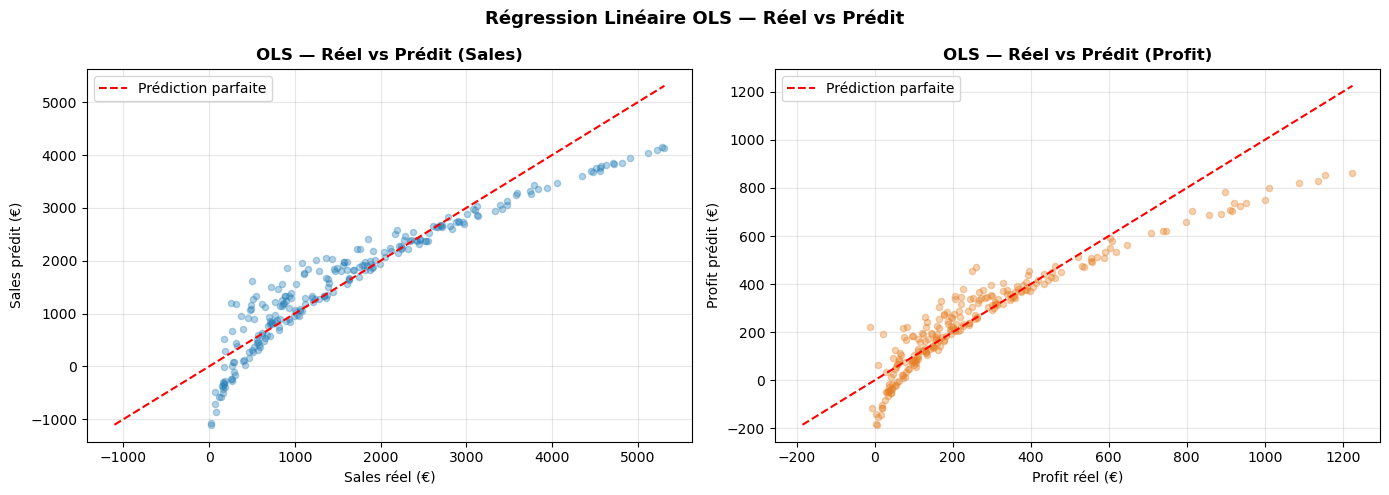

In [38]:
# Réel vs Prédit — OLS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, label, color in zip(
    axes, [ys_test, yp_test], [ys_pred_lr, yp_pred_lr],
    ['Sales', 'Profit'], ['#2980b9', '#e67e22']):
    ax.scatter(y_true, y_pred, alpha=0.35, color=color, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
    ax.set_title(f'OLS — Réel vs Prédit ({label})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{label} réel (€)'); ax.set_ylabel(f'{label} prédit (€)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Régression Linéaire OLS — Réel vs Prédit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Hyperparamètres communs
gbr_params = dict(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Modèle Sales
gbr_sales = GradientBoostingRegressor(**gbr_params)
gbr_sales.fit(X_train, ys_train)
ys_pred = gbr_sales.predict(X_test)

# Modèle Profit
gbr_profit = GradientBoostingRegressor(**gbr_params)
gbr_profit.fit(X_train, yp_train)
yp_pred = gbr_profit.predict(X_test)

print(' Modèles Gradient Boosting entraînés')

 Modèles Gradient Boosting entraînés


In [40]:
mae_s, rmse_s, r2_s = metrics(ys_test, ys_pred,  'GBR — Sales')
mae_p, rmse_p, r2_p = metrics(yp_test, yp_pred,  'GBR — Profit')

📊 GBR — Sales
   MAE  :      27.02
   RMSE :      37.72
   R²   :     0.9991

📊 GBR — Profit
   MAE  :      19.61
   RMSE :      27.47
   R²   :     0.9876



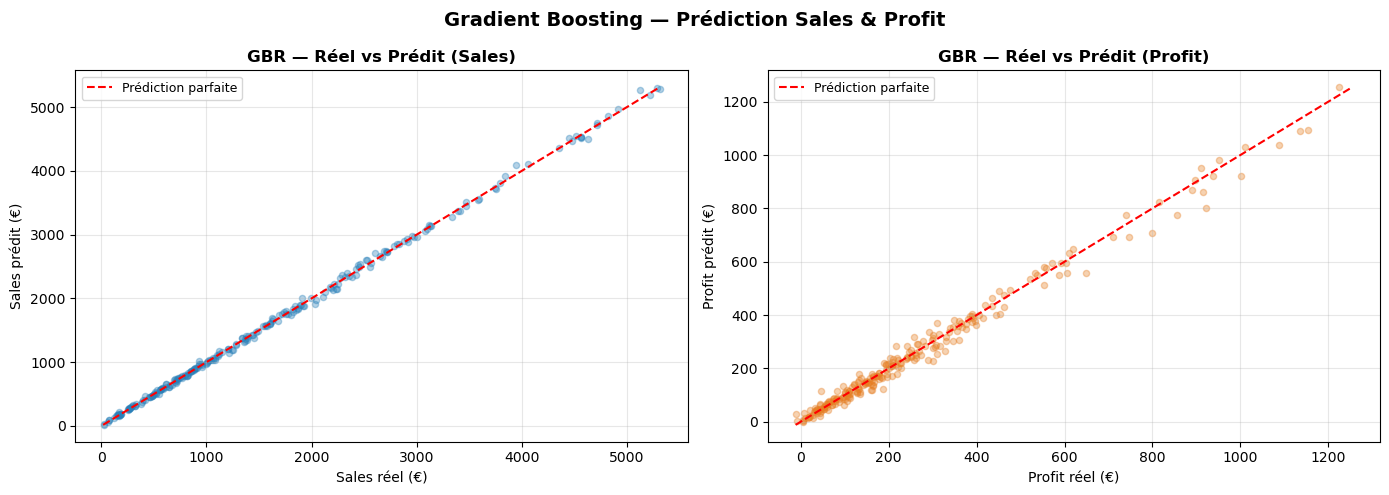

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, label, color in zip(
    axes,
    [ys_test, yp_test],
    [ys_pred, yp_pred],
    ['Sales', 'Profit'],
    ['#2980b9', '#e67e22']
):
    ax.scatter(y_true, y_pred, alpha=0.35, color=color, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
    ax.set_title(f'GBR — Réel vs Prédit ({label})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{label} réel (€)')
    ax.set_ylabel(f'{label} prédit (€)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting — Prédiction Sales & Profit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

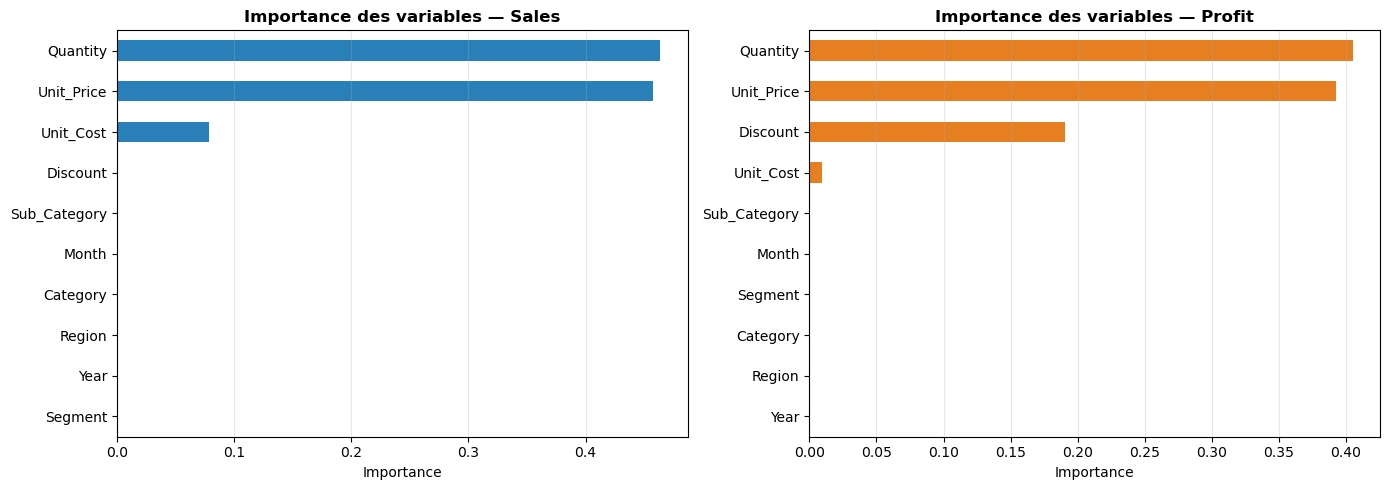

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, label, color in zip(
    axes,
    [gbr_sales, gbr_profit],
    ['Sales', 'Profit'],
    ['#2980b9', '#e67e22']
):
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Importance des variables — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [43]:
# Agrégation par mois
monthly = df.groupby('Date')[['Sales', 'Profit']].sum().reset_index().sort_values('Date')

# Séries Prophet (format obligatoire ds / y)
ts_sales  = monthly.rename(columns={'Date': 'ds', 'Sales':  'y'})[['ds', 'y']]
ts_profit = monthly.rename(columns={'Date': 'ds', 'Profit': 'y'})[['ds', 'y']]

print(f'Points mensuels : {len(monthly)}')
monthly.tail()

Points mensuels : 48


,Date,Sales,Profit
43,2025-08-01,45594.90,7272.16
44,2025-09-01,26359.44,3907.78
45,2025-10-01,39410.40,6399.33
46,2025-11-01,43654.54,7837.33
47,2025-12-01,45195.81,7210.56


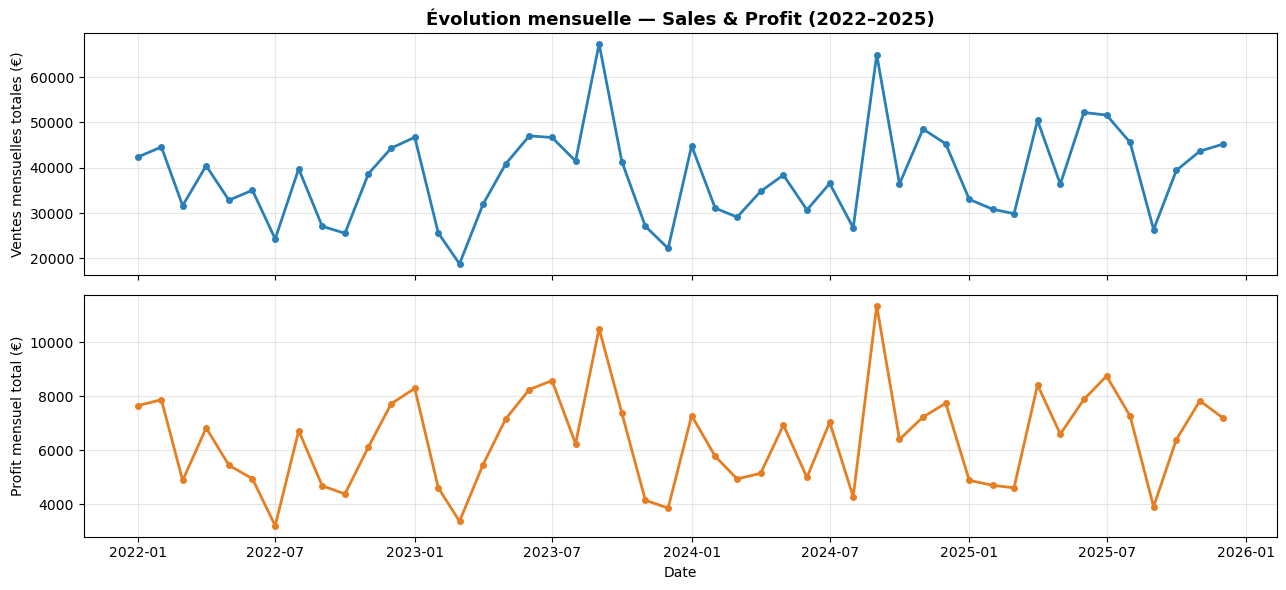

In [44]:
# Visualisation de la série brute
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, col, color, label in zip(
    axes,
    ['Sales', 'Profit'],
    ['#2980b9', '#e67e22'],
    ['Ventes mensuelles totales (€)', 'Profit mensuel total (€)']
):
    ax.plot(monthly['Date'], monthly[col], 'o-', color=color, linewidth=2, markersize=4)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Évolution mensuelle — Sales & Profit (2022–2025)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [45]:
CUTOFF = '2024-12-01'

train_s = ts_sales[ts_sales['ds']  <= CUTOFF]
test_s  = ts_sales[ts_sales['ds']  >  CUTOFF]
train_p = ts_profit[ts_profit['ds'] <= CUTOFF]
test_p  = ts_profit[ts_profit['ds'] >  CUTOFF]

print(f'Train : {len(train_s)} mois | Test : {len(test_s)} mois')

Train : 36 mois | Test : 12 mois


In [46]:
prophet_params = dict(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

# Modèle Sales
m_sales = Prophet(**prophet_params)
m_sales.fit(train_s)

# Modèle Profit
m_profit = Prophet(**prophet_params)
m_profit.fit(train_p)

print(' Modèles Prophet entraînés')

08:53:05 - cmdstanpy - INFO - Chain [1] start processing
08:53:06 - cmdstanpy - INFO - Chain [1] done processing
08:53:06 - cmdstanpy - INFO - Chain [1] start processing
08:53:07 - cmdstanpy - INFO - Chain [1] done processing


 Modèles Prophet entraînés


In [47]:
# Prédictions sur 12 mois futurs
future_s = m_sales.make_future_dataframe(periods=12, freq='MS')
future_p = m_profit.make_future_dataframe(periods=12, freq='MS')

fc_sales  = m_sales.predict(future_s)
fc_profit = m_profit.predict(future_p)

# Métriques sur la période de test
def prophet_metrics(fc, test_df, label):
    pred = fc[fc['ds'].isin(test_df['ds'])]['yhat'].values
    true = test_df['y'].values
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    print(f'📊 Prophet — {label}')
    print(f'   MAE  : {mae:>10.2f}')
    print(f'   RMSE : {rmse:>10.2f}')
    print(f'   R²   : {r2:>10.4f}\n')
    return pred, true, mae, rmse, r2

pred_s, true_s, mae_ps, rmse_ps, r2_ps = prophet_metrics(fc_sales,  test_s, 'Sales')
pred_p, true_p, mae_pp, rmse_pp, r2_pp = prophet_metrics(fc_profit, test_p, 'Profit')

📊 Prophet — Sales
   MAE  :    9034.63
   RMSE :   11882.57
   R²   :    -0.8852

📊 Prophet — Profit
   MAE  :    1607.34
   RMSE :    2184.65
   R²   :    -0.9250



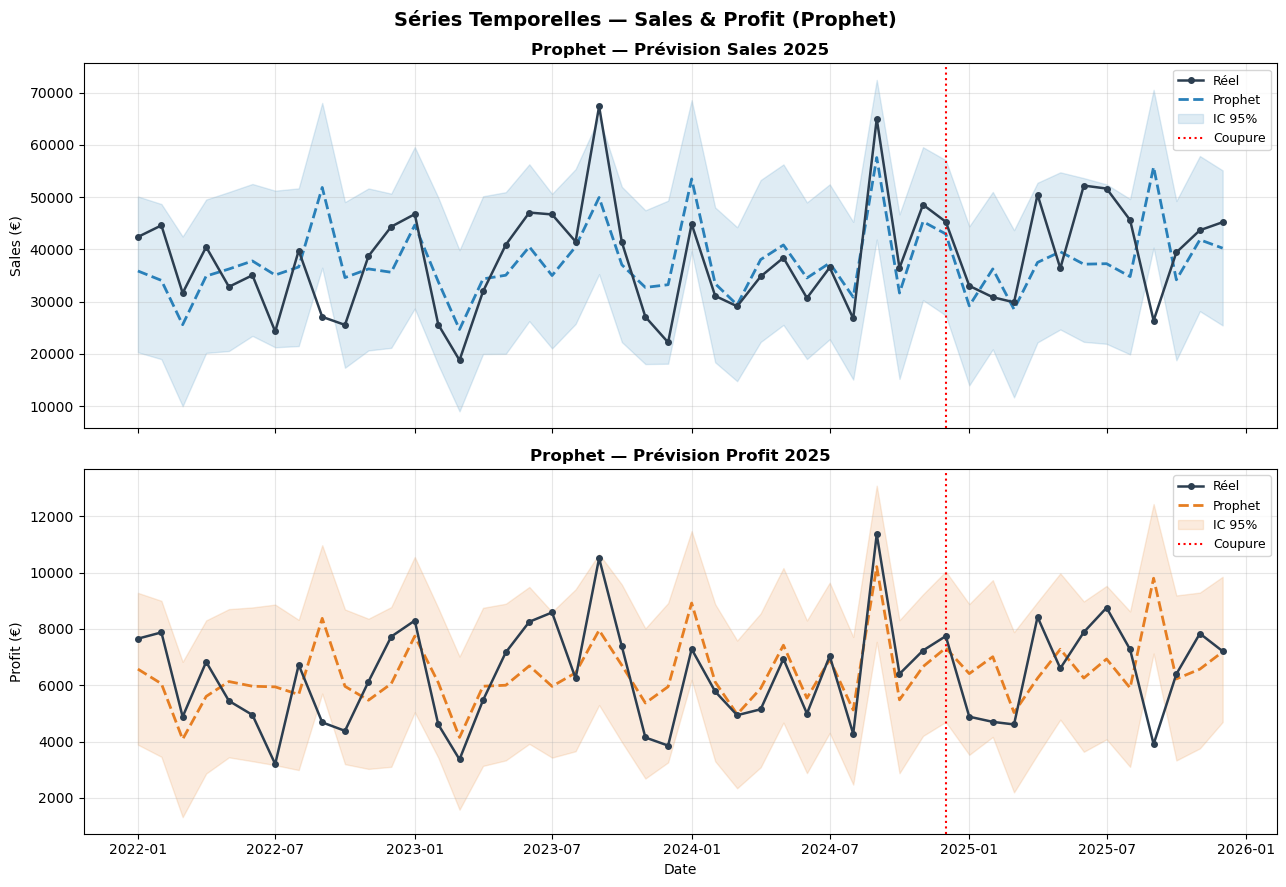

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

configs = [
    (ts_sales,  fc_sales,  test_s, 'Sales',  '#2980b9'),
    (ts_profit, fc_profit, test_p, 'Profit', '#e67e22'),
]

for ax, (ts, fc, test, label, color) in zip(axes, configs):
    # Historique
    ax.plot(ts['ds'], ts['y'], 'o-', color='#2c3e50', linewidth=1.8,
            markersize=4, label='Réel', zorder=3)
    # Prévision
    ax.plot(fc['ds'], fc['yhat'], '--', color=color, linewidth=2, label='Prophet')
    # IC 95%
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    color=color, alpha=0.15, label='IC 95%')
    # Coupure
    ax.axvline(pd.to_datetime(CUTOFF), color='red', linestyle=':', lw=1.5, label='Coupure')
    ax.set_ylabel(f'{label} (€)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Prophet — Prévision {label} 2025', fontsize=12, fontweight='bold')

axes[1].set_xlabel('Date')
plt.suptitle('Séries Temporelles — Sales & Profit (Prophet)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

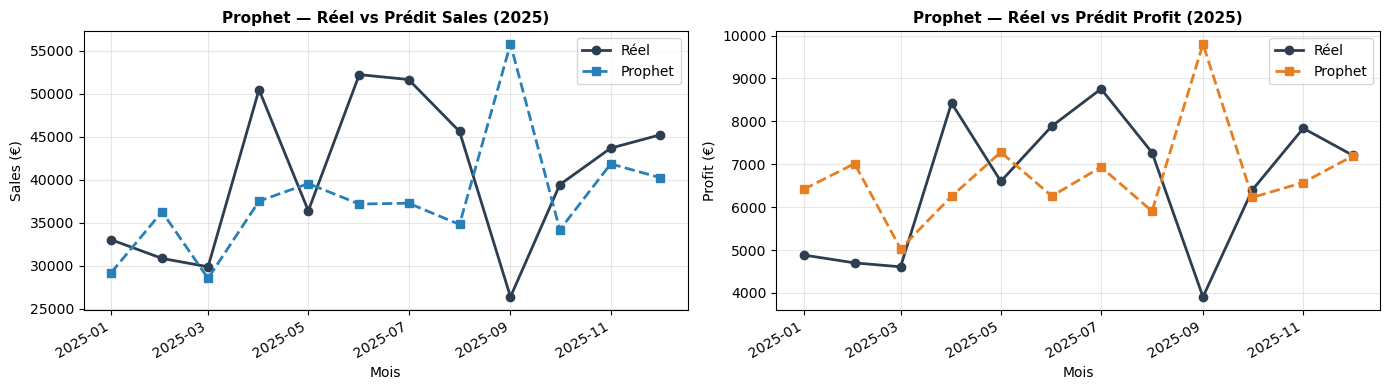

In [49]:
# Réel vs Prédit 2025 — zoom sur la période de test
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, test, pred, true, label, color in zip(
    axes,
    [test_s,  test_p],
    [pred_s,  pred_p],
    [true_s,  true_p],
    ['Sales', 'Profit'],
    ['#2980b9', '#e67e22']
):
    ax.plot(test['ds'].values, true, 'o-', color='#2c3e50', label='Réel', lw=2)
    ax.plot(test['ds'].values, pred, 's--', color=color, label='Prophet', lw=2)
    ax.set_title(f'Prophet — Réel vs Prédit {label} (2025)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mois')
    ax.set_ylabel(f'{label} (€)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

=== Composantes Prophet — Sales ===


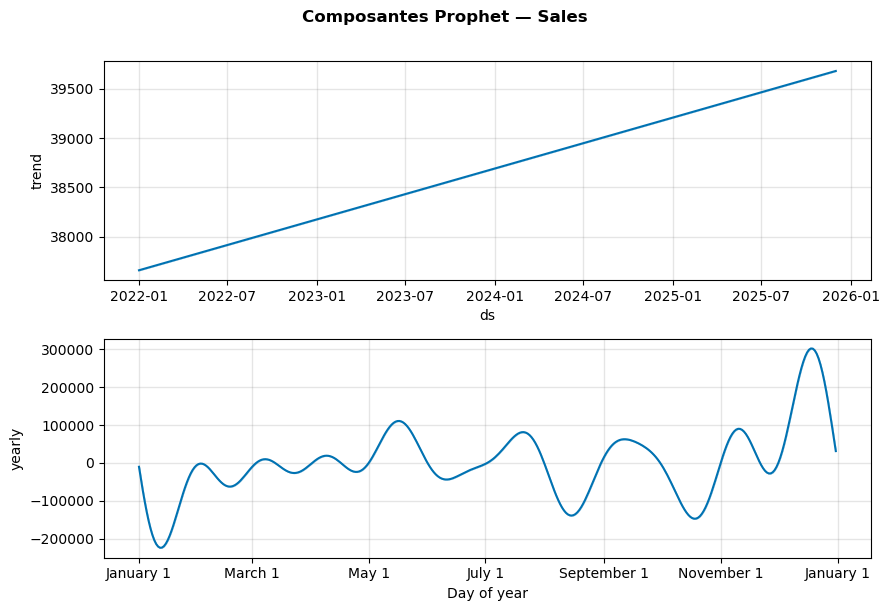

=== Composantes Prophet — Profit ===


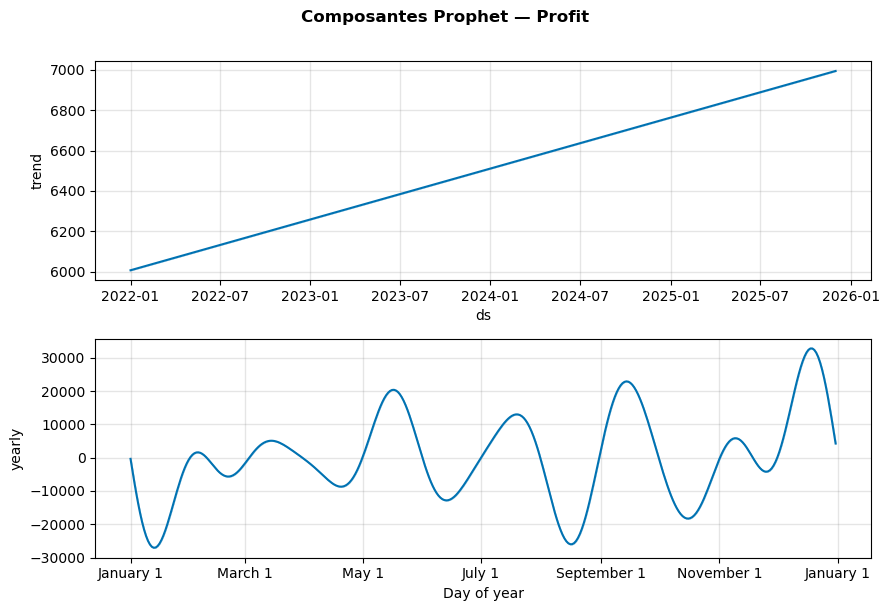

In [50]:
# Décomposition des composantes Prophet
print('=== Composantes Prophet — Sales ===')
fig_s = m_sales.plot_components(fc_sales)
plt.suptitle('Composantes Prophet — Sales', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('=== Composantes Prophet — Profit ===')
fig_p = m_profit.plot_components(fc_profit)
plt.suptitle('Composantes Prophet — Profit', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [51]:
# Tableau de synthèse — 3 modèles x 2 cibles
summary = pd.DataFrame([
    {'Cible': 'Sales',  'Modèle': 'Régression Linéaire (OLS)', 'MAE': round(mae_lrs, 2), 'RMSE': round(rmse_lrs, 2), 'R²': round(r2_lrs, 4)},
    {'Cible': 'Sales',  'Modèle': 'Gradient Boosting',         'MAE': round(mae_s, 2),   'RMSE': round(rmse_s, 2),   'R²': round(r2_s, 4)},
    {'Cible': 'Sales',  'Modèle': 'Prophet (mensuel)',          'MAE': round(mae_ps, 2),  'RMSE': round(rmse_ps, 2),  'R²': round(r2_ps, 4)},
    {'Cible': 'Profit', 'Modèle': 'Régression Linéaire (OLS)', 'MAE': round(mae_lrp, 2), 'RMSE': round(rmse_lrp, 2), 'R²': round(r2_lrp, 4)},
    {'Cible': 'Profit', 'Modèle': 'Gradient Boosting',         'MAE': round(mae_p, 2),   'RMSE': round(rmse_p, 2),   'R²': round(r2_p, 4)},
    {'Cible': 'Profit', 'Modèle': 'Prophet (mensuel)',          'MAE': round(mae_pp, 2),  'RMSE': round(rmse_pp, 2),  'R²': round(r2_pp, 4)},
])

print('=== Synthèse des performances — 3 modèles ===')
print(summary.to_string(index=False))

=== Synthèse des performances — 3 modèles ===
 Cible                    Modèle     MAE     RMSE      R²
 Sales Régression Linéaire (OLS)  320.11   432.77  0.8857
 Sales         Gradient Boosting   27.02    37.72  0.9991
 Sales         Prophet (mensuel) 9034.63 11882.57 -0.8852
Profit Régression Linéaire (OLS)   61.62    88.91  0.8704
Profit         Gradient Boosting   19.61    27.47  0.9876
Profit         Prophet (mensuel) 1607.34  2184.65 -0.9250


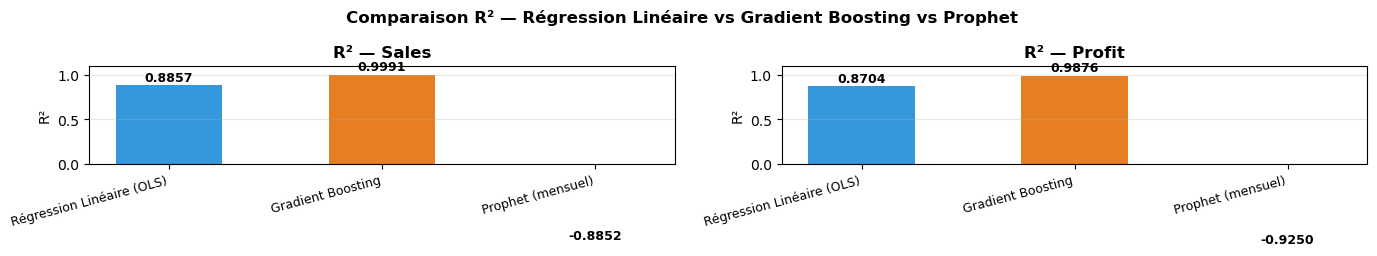

In [52]:
# Graphique comparatif R² — 3 modèles x 2 cibles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cible in zip(axes, ['Sales', 'Profit']):
    sub = summary[summary['Cible'] == cible]
    colors = ['#3498db', '#e67e22', '#8e44ad']
    bars = ax.bar(sub['Modèle'], sub['R²'], color=colors, width=0.5)
    ax.set_title(f'R² — {cible}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('R²')
    ax.set_xticklabels(sub['Modèle'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, sub['R²']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison R² — Régression Linéaire vs Gradient Boosting vs Prophet',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# Tableau des prédictions Prophet 2025 (mois par mois)
prev_2025 = pd.DataFrame({
    'Mois'            : fc_sales[fc_sales['ds'] > CUTOFF]['ds'].dt.strftime('%Y-%m').values,
    'Sales_Prévu'     : fc_sales[fc_sales['ds']  > CUTOFF]['yhat'].round(2).values,
    'Sales_IC_Low'    : fc_sales[fc_sales['ds']  > CUTOFF]['yhat_lower'].round(2).values,
    'Sales_IC_High'   : fc_sales[fc_sales['ds']  > CUTOFF]['yhat_upper'].round(2).values,
    'Profit_Prévu'    : fc_profit[fc_profit['ds'] > CUTOFF]['yhat'].round(2).values,
    'Profit_IC_Low'   : fc_profit[fc_profit['ds'] > CUTOFF]['yhat_lower'].round(2).values,
    'Profit_IC_High'  : fc_profit[fc_profit['ds'] > CUTOFF]['yhat_upper'].round(2).values,
})

print('=== Prévisions Prophet 2025 — Sales & Profit ===')
print(prev_2025.to_string(index=False))

=== Prévisions Prophet 2025 — Sales & Profit ===
   Mois  Sales_Prévu  Sales_IC_Low  Sales_IC_High  Profit_Prévu  Profit_IC_Low  Profit_IC_High
2025-01     29177.39      13959.36       44399.69       6414.15        3530.20         8884.99
2025-02     36249.27      20858.96       50987.24       7013.61        4164.70         9732.98
2025-03     28513.12      11647.49       43661.59       5030.05        2194.99         7886.58
2025-04     37495.31      22185.77       52741.60       6251.83        3538.84         8958.57
2025-05     39535.32      24655.50       54740.75       7279.87        4779.32         9974.22
2025-06     37151.96      22289.39       53633.75       6256.93        3638.71         8978.02
2025-07     37250.30      21908.85       52430.71       6933.86        4080.54         9529.01
2025-08     34780.51      19884.11       49628.21       5905.62        3101.99         8622.43
2025-09     55765.14      40342.35       70539.04       9802.61        7128.82        12436.89
2

In [54]:
future_data = pd.DataFrame({
    'Region': [1, 2, 3],        
    'Segment': [0, 1, 0],       
    'Category': [2, 1, 0],      
    'Sub_Category': [5, 10, 3],
    'Year': [2026, 2026, 2026], 
    'Month': [1, 1, 1],        
    'Quantity': [5, 10, 2],      
    'Unit_Cost': [150.0, 200.0, 50.0], 
    'Unit_Price': [180.0, 250.0, 70.0],
    'Discount': [0.1, 0.15, 0.05]
})

predicted_sales_2026 = gbr_sales.predict(future_data)
predicted_profit_2026 = gbr_profit.predict(future_data)

future_data['Predicted_Sales'] = predicted_sales_2026
future_data['Predicted_Profit'] = predicted_profit_2026

print("Prédictions des ventes et bénéfices - Année 2026 :")
print(future_data[['Year', 'Month', 'Predicted_Sales', 'Predicted_Profit']])

Prédictions des ventes et bénéfices - Année 2026 :
   Year  Month  Predicted_Sales  Predicted_Profit
0  2026      1       915.519280        151.870348
1  2026      1      2206.847103        276.985091
2  2026      1       158.777641         41.608034


In [58]:
df_2026 = pd.DataFrame({
    'Region': [1, 2, 3],        
    'Segment': [0, 1, 0],       
    'Category': [2, 1, 0],      
    'Sub_Category': [5, 10, 3],
    'Year': [2026, 2026, 2026], 
    'Month': [1, 1, 1],        
    'Quantity': [5, 10, 2],      
    'Unit_Cost': [150.0, 200.0, 50.0], 
    'Unit_Price': [180.0, 250.0, 70.0],
    'Discount': [0.1, 0.15, 0.05]
})

X_2026_scaled = scaler.transform(df_2026)
predictions_sales_2026 = lr_sales.predict(X_2026_scaled)
predictions_profit_2026 = lr_profit.predict(X_2026_scaled)
df_2026['Predicted_Sales'] = predictions_sales_2026
df_2026['Predicted_Profit'] = predictions_profit_2026
print("Prévisions des ventes et des profits via Régression Linéaire (OLS) 2026 :")
print(df_2026[['Year', 'Month', 'Predicted_Sales', 'Predicted_Profit']])

Prévisions des ventes et des profits via Régression Linéaire (OLS) 2026 :
   Year  Month  Predicted_Sales  Predicted_Profit
0  2026      1       869.449720        144.005966
1  2026      1      2787.634668        496.406647
2  2026      1      -540.486693        -53.077907
